In [1]:
import sys
sys.path.append('..')

from shipClass.Ship import Ship
from shipClass.SensedShip import SensedShip

import numpy.random as npr
npr.seed(17)  # for reproducibility

Changing the number of sensors on each ship

In [ ]:
from utils.helperFunctions import create_multi_simulation_table
import numpy as np

# NOTE: can run all simulation parameter for 10 simulations in about 2 minutes (without plotting) or in about 8 minutes (with plotting)

# specify (sensor number and quality) for each simulation
# specify (sensor number and quality) for each simulation
# simulation_parameters =[ (1, 'bad'),         # 1 bad quality sensor per component
#                          (1, 'moderate'),   # 1 moderate quality sensor per component
#                          (1, 'good')]       # 1 good quality sensor per component

simulation_parameters =[ (1, 'bad'),         # 1 bad quality sensor per component
                         (1, 'moderate'),   # 1 moderate quality sensor per component
                         (1, 'good'),       # 1 good quality sensor per component
                         (3, 'bad'),        # 3 bad quality sensors per component
                         (3, 'moderate'),   # 3 moderate quality sensors per component
                         (3, 'good'),       # 3 good quality sensors per component
                         (7, 'bad'),        # 7 bad quality sensors per component
                         (7, 'moderate'),   # 7 moderate quality sensors per component
                         (7, 'good')]       # 7 good quality sensors per component
num_simulations = 10   # number of times to run each simulation parameter

# set up lists for storing relevant data
count_false_alarms = np.zeros((len(simulation_parameters), num_simulations)) # percent of total incipent failures that were actually working
count_unexpected_failures = np.zeros((len(simulation_parameters), num_simulations)) # percent of total failures that were unexpected (not predicted by sensors)


# initialize a repairable ship
repairable_aux_ship = Ship('RepairableShip', 
                          'AuxilaryPropulsionPlant_Reliability_Availability_Data.xlsx', 
                          repairable=True)

# run the simulations
for i in range(len(simulation_parameters)):
    print("simulation_parameters: Number of Sensors = ", simulation_parameters[i][0], ", Sensor Quality = ", simulation_parameters[i][1])
    
    for j in range(num_simulations):
        print(f"Simulation {j+1} of {num_simulations}")

        # attach sensors to the ship ( base case = 1 sensor, bad quality ) 
        sensors = [[simulation_parameters[i] for comps in system.comps] for system in repairable_aux_ship.systems.values()]  # number of sensors per component, sensor quality
        sensed_R_aux_ship = SensedShip(repairable_aux_ship)
        sensed_R_aux_ship.attach_sensors()                    # attach sensors to each system

        sensed_R_aux_ship.simulate(720)  # simulate for 720 hours (30 days)
        # sensed_R_aux_ship.plotHistory()

        # calculate relevant data
        count_false_alarms[i][j] = sensed_R_aux_ship.getFalseAlarmRate()
        count_unexpected_failures[i][j] = sensed_R_aux_ship.getUnexpectedFailureRate()

        # reset the ship for the next simulation
        sensed_R_aux_ship.reset()

# print out results
headers = ["Simulation Parameters", "False Alarm (%)", "Unexpected Failure (%)"]
rows = []
for i in range(len(simulation_parameters)):
    rows.append([simulation_parameters[i], count_false_alarms[i].mean(), count_unexpected_failures[i].mean()]) # averages for each simulation parameter

print(create_multi_simulation_table(headers, rows))



simulation_parameters: Number of Sensors =  1 , Sensor Quality =  bad
Simulation 1 of 10
Simulation 2 of 10
Simulation 3 of 10
Simulation 4 of 10
Simulation 5 of 10
Simulation 6 of 10
Simulation 7 of 10
Simulation 8 of 10
Simulation 9 of 10
Simulation 10 of 10
simulation_parameters: Number of Sensors =  1 , Sensor Quality =  moderate
Simulation 1 of 10
Simulation 2 of 10
Simulation 3 of 10
Simulation 4 of 10
Simulation 5 of 10
Simulation 6 of 10
Simulation 7 of 10
Simulation 8 of 10
Simulation 9 of 10
Simulation 10 of 10
simulation_parameters: Number of Sensors =  1 , Sensor Quality =  good
Simulation 1 of 10
Simulation 2 of 10
Simulation 3 of 10
Simulation 4 of 10
Simulation 5 of 10
Simulation 6 of 10
Simulation 7 of 10
Simulation 8 of 10
Simulation 9 of 10
Simulation 10 of 10
simulation_parameters: Number of Sensors =  3 , Sensor Quality =  bad
Simulation 1 of 10
Simulation 2 of 10
Simulation 3 of 10
Simulation 4 of 10
Simulation 5 of 10
Simulation 6 of 10
Simulation 7 of 10
Simulati

Simulate n non-repairable auxillary ships

In [3]:
from utils.RAM_Functions import calculate_availability
from utils.RAM_Functions import calculate_sensor_reliability

numpy.random.seed(12)  # for reproducibility

num_simulations = 100   # number of times to run the non-repairable ship simulation

# initialize a non-repairable ship
no_repair_aux_ship = Ship('noRepairShip', 'AuxilaryPropulsionPlant_Reliability_Availability_Data.xlsx', repairable=False)
sensed_NR_aux_ship = SensedShip(no_repair_aux_ship)
sensed_NR_aux_ship.attach_sensors()  # attach sensors to each system

failure_times = []  # failure time for each simulation
availability = []   # availability for each simulation
ship_histories = {} # store the truth and sensed histories for each simulation

# run n simulations and record relevant data
for i in range(num_simulations):

    # print iteration number
    print(i+1)

    # simulate until ship fails
    while(sensed_NR_aux_ship.ship.state > 0):  # simulate until ship fails
        sensed_NR_aux_ship.simulate(1)

        if len(sensed_NR_aux_ship.ship.history) > 350000:  # prevent infinite loop, assume max operation time = 350,000 hours
            print("Ship did not fail within 350,000 hours, stopping simulation")
            break

    # determine when the ship failed (or when simulation stopped) and to list for reliability curve plotting
    failure_times.append(len(sensed_NR_aux_ship.ship.history))
    
    # store ship history for this simulation
    ship_histories[f'Simulation_{i+1}'] = (sensed_NR_aux_ship.ship.history, sensed_NR_aux_ship.sensedHistory)

    # optional: plot the ship's state history
    # sensed_NR_aux_ship.plotHistory()

    # reset ship for next simulation
    sensed_NR_aux_ship.reset()

NameError: name 'numpy' is not defined

Calculate Reliability for the simulated ships

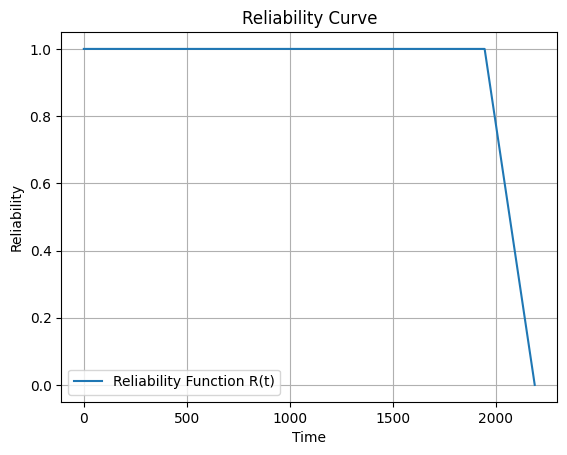

Reliability at 720 Hours: 100.00%
Average Availability: 69.68%
Min Failure Time: 2190 hours
Max Failure Time: 2190 hours
Mean Failure Time: 2190.00 hours
Median Failure Time: 2190 hours
Mode Failure Time: 2190 hours


In [ ]:
from utils.RAM_Functions import drawRelCurve
from utils.helperFunctions import find_mode

# Draw Reliability Curve
drawRelCurve(failure_times)

# Calculate Reliability at 720 Hours
reliability_at_720 = sum(1 for time in failure_times if time >= 720) / num_simulations
print(f"Reliability at 720 Hours: {reliability_at_720*100:.2f}%")

# print average availability
average_availability = sum(availability) / num_simulations
print(f"Average Availability: {average_availability*100:.2f}%")

# Calculate relevant failure statistics
min_failure_times = min(failure_times)
max_failure_times = max(failure_times)
mean_failure_time = sum(failure_times) / num_simulations
median_failure_time = sorted(failure_times)[num_simulations // 2]
mode_failure_time = find_mode(failure_times)
print(f"Min Failure Time: {min_failure_times} hours")
print(f"Max Failure Time: {max_failure_times} hours")
print(f"Mean Failure Time: {mean_failure_time:.2f} hours")
print(f"Median Failure Time: {median_failure_time} hours")
print(f"Mode Failure Time: {mode_failure_time} hours")


simulate n repairable ships for three months (2190 hours)

In [ ]:
from utils.RAM_Functions import calculate_availability
from utils.RAM_Functions import calculate_sensor_reliability

numpy.random.seed(12)  # for reproducibility

num_simulations = 100   # number of times to run the non-repairable ship simulation

# initialize a non-repairable ship
no_repair_aux_ship = Ship('noRepairShip', 'AuxilaryPropulsionPlant_Reliability_Availability_Data.xlsx', repairable=False)
sensed_NR_aux_ship = SensedShip(no_repair_aux_ship)
sensed_NR_aux_ship.attach_sensors()  # attach sensors to each system

failure_times = []  # failure time for each simulation
availability = []   # availability for each simulation
ship_histories = {} # store the truth and sensed histories for each simulation

# run n simulations and record relevant data
for i in range(num_simulations):

    # print iteration number
    print(i+1)

    # simulate for three months (2190 hours)
    sensed_NR_aux_ship.simulate(2190)  

    # determine the ships availability for this simulation
    availability.append(calculate_availability(sensed_NR_aux_ship.ship.history))

    # store ship history for this simulation
    ship_histories[f'Simulation_{i+1}'] = (sensed_NR_aux_ship.ship.history, sensed_NR_aux_ship.sensedHistory)

    # optional: plot the ship's state history
    # sensed_NR_aux_ship.plotHistory()

    # reset ship for next simulation
    sensed_NR_aux_ship.reset()


truth_histories = [v[0] for v in ship_histories.values()]
sensed_histories = [v[1] for v in ship_histories.values()]

sensor_reliability_table = calculate_sensor_reliability(truth_histories, sensed_histories)
print(sensor_reliability_table)

Calculate sensor reliability numbers for an additional simulation